<a href="https://colab.research.google.com/github/Arrsssa/-/blob/main/%EC%95%B1%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_2555038_04_03_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install requests beautifulsoup4 pandas scipy matplotlib

# 1단계: 첫 20권 제목 가져오기

In [6]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://books.toscrape.com/catalogue/page-1.html"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

titles = []
for h3 in soup.find_all("h3"):
    a_tag = h3.find("a")
    titles.append(a_tag["title"])  # 텍스트가 아닌 title 속성값 추출

df_20 = pd.DataFrame(titles, columns=["Title"])
print(df_20)

                                                Title
0                                A Light in the Attic
1                                  Tipping the Velvet
2                                          Soumission
3                                       Sharp Objects
4               Sapiens: A Brief History of Humankind
5                                     The Requiem Red
6   The Dirty Little Secrets of Getting Your Dream...
7   The Coming Woman: A Novel Based on the Life of...
8   The Boys in the Boat: Nine Americans and Their...
9                                     The Black Maria
10     Starving Hearts (Triangular Trade Trilogy, #1)
11                              Shakespeare's Sonnets
12                                        Set Me Free
13  Scott Pilgrim's Precious Little Life (Scott Pi...
14                          Rip it Up and Start Again
15  Our Band Could Be Your Life: Scenes from the A...
16                                               Olio
17  Mesaerion: The Best Scie

# 2단계: 100권 제목 가져오기 (5페이지 × 20권)

In [7]:
titles_100 = []

for page in range(1, 6):  # 1~5페이지
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    for h3 in soup.find_all("h3"):
        titles_100.append(h3.find("a")["title"])

df_100 = pd.DataFrame(titles_100, columns=["Title"])
print(df_100)

                                                Title
0                                A Light in the Attic
1                                  Tipping the Velvet
2                                          Soumission
3                                       Sharp Objects
4               Sapiens: A Brief History of Humankind
..                                                ...
95  Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...
96  Layered: Baking, Building, and Styling Spectac...
97  Judo: Seven Steps to Black Belt (an Introducto...
98                                               Join
99          In the Country We Love: My Family Divided

[100 rows x 1 columns]


# 3단계: 10개 카테고리에서 각 10권씩 수집

In [8]:
categories = {
    "Travel": "travel_2",
    "Mystery": "mystery_3",
    "Historical Fiction": "historical-fiction_4",
    "Sequential Art": "sequential-art_5",
    "Classics": "classics_6",
    "Philosophy": "philosophy_7",
    "Romance": "romance_8",
    "Womens Fiction": "womens-fiction_9",
    "Fiction": "fiction_10",
    "Childrens": "childrens_11",
}

books_data = []

for category_name, category_slug in categories.items():
    url = f"https://books.toscrape.com/catalogue/category/books/{category_slug}/index.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    articles = soup.find_all("article", class_="product_pod")[:10] # 카테고리별 10권만
    for article in articles:
        title = article.find("h3").find("a")["title"]
        price = article.find("p", class_="price_color").text.strip()
        books_data.append({
            "Category": category_name,
            "Title": title,
            "Price": price
        })

df_books = pd.DataFrame(books_data)

# £ 기호 제거 후 숫자형으로 변환
df_books["Price_Numeric"] = df_books["Price"].str.replace("£", "").str.replace("Â", "").astype(float)

# 가장 비싼 책 10권 추출
top10 = df_books.sort_values(by="Price_Numeric", ascending=False).head(10)
print(top10)

              Category                                              Title  \
46            Classics                                            Candide   
51          Philosophy       The Death of Humanity: and the Case for Life   
93           Childrens  The White Cat and the Monk: A Retelling of the...   
70      Womens Fiction  I Had a Nice Time And Other Lies...: How to fi...   
47            Classics                                        Animal Farm   
7               Travel                   A Year in Provence (Provence #1)   
12             Mystery                                The Past Never Ends   
92           Childrens                    The Secret of Dreadwillow Carse   
66             Romance                   Suddenly in Love (Lake Haven #1)   
22  Historical Fiction            A Flight of Arrows (The Pathfinders #2)   

      Price  Price_Numeric  
46  Â£58.63          58.63  
51  Â£58.11          58.11  
93  Â£58.08          58.08  
70  Â£57.36          57.36  
47  Â£5

# 4단계: 정규분포 검정

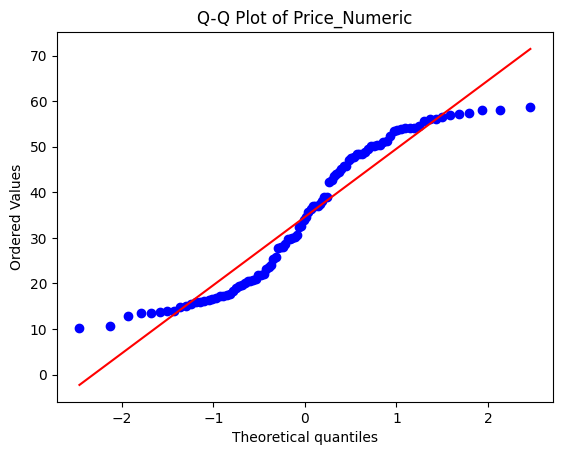

Shapiro-Wilk Statistic: 0.9158
P-value: 0.0000
→ 정규분포를 따르지 않음 (p < 0.05)


In [9]:
import matplotlib.pyplot as plt
import scipy.stats as stats

prices = df_books["Price_Numeric"]

# Q-Q 플롯 시각화
fig, ax = plt.subplots()
stats.probplot(prices, dist="norm", plot=ax)
ax.set_title("Q-Q Plot of Price_Numeric")
plt.show()

# 샤피로-윌크 검정
stat, p_value = stats.shapiro(prices)
print(f"Shapiro-Wilk Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value > 0.05:
    print("→ 정규분포를 따름 (p > 0.05)")
else:
    print("→ 정규분포를 따르지 않음 (p < 0.05)")